In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # prevent wrapping

data = pd.read_csv('../data/raw/dataset.csv')

print(data.shape)
print("\n")
print("---------------------Datatypes--------------------------")
print(data.dtypes)
print("\n")
print("---------------------Null values--------------------------")
print(data.isnull().sum())
print("\n")
print("---------------------First few rows--------------------------")
print(data.head())
print("\n")
print("---------------------Data Description--------------------------")
print(data.describe())

(114000, 21)


---------------------Datatypes--------------------------
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


---------------------Null values--------------------------
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
m

In [3]:
# Dropping the 'Unnamed: 0' column as it is an index column and does not provide any useful information for analysis.
data = data.drop(columns=['Unnamed: 0'])

print(data.dtypes.value_counts())

float64    9
object     5
int64      5
bool       1
Name: count, dtype: int64


In [4]:
# dropping the rows with null values as they are very few and will not affect the analysis significantly.
data = data.dropna(subset=['artists', 'album_name', 'track_name'])
print(data.isnull().sum().sum())
print(data.shape)
print(data.dtypes.value_counts())

0
(113999, 20)
float64    9
object     5
int64      5
bool       1
Name: count, dtype: int64


In [5]:
# the object and bool datatypes are used in clustering
print('Object Columns: ', data.select_dtypes('object').columns.to_list())
print('Bool Columns: ', data.select_dtypes('bool').columns.to_list())

Object Columns:  ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']
Bool Columns:  ['explicit']


In [6]:
print(data.columns.to_list())

['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [7]:
AUDIO_FEATURES = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

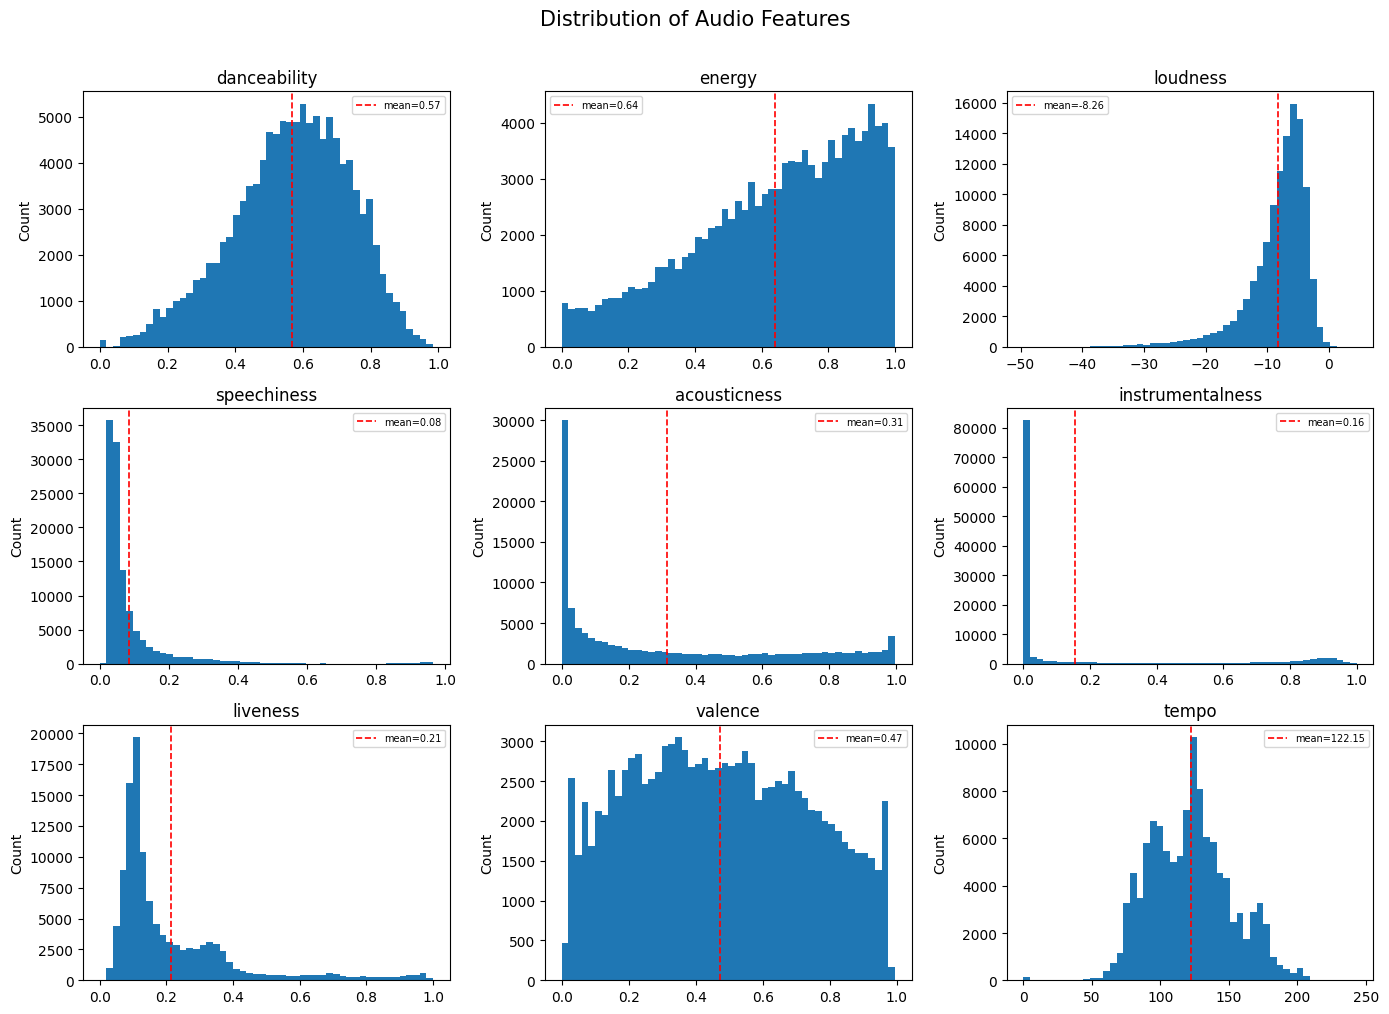

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Distribution of Audio Features', fontsize=15, y=1.01)

for ax, feat in zip(axes.flat, AUDIO_FEATURES):
    ax.hist(data[feat], bins=50, edgecolor=None)
    ax.set_title(feat)
    ax.set_ylabel('Count')
    mu = data[feat].mean()
    ax.axvline(mu, color="red", linestyle="--", linewidth=1.2, label=f"mean={mu:.2f}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("../outputs/figures/01_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

- speechiness, acousticness, instrumentalness, liveness will be log-transformed due to their zero-inflating nature (log-transform helps the model distinguish between two close points easily)
- all remaining features will be transformed using StandardScaler

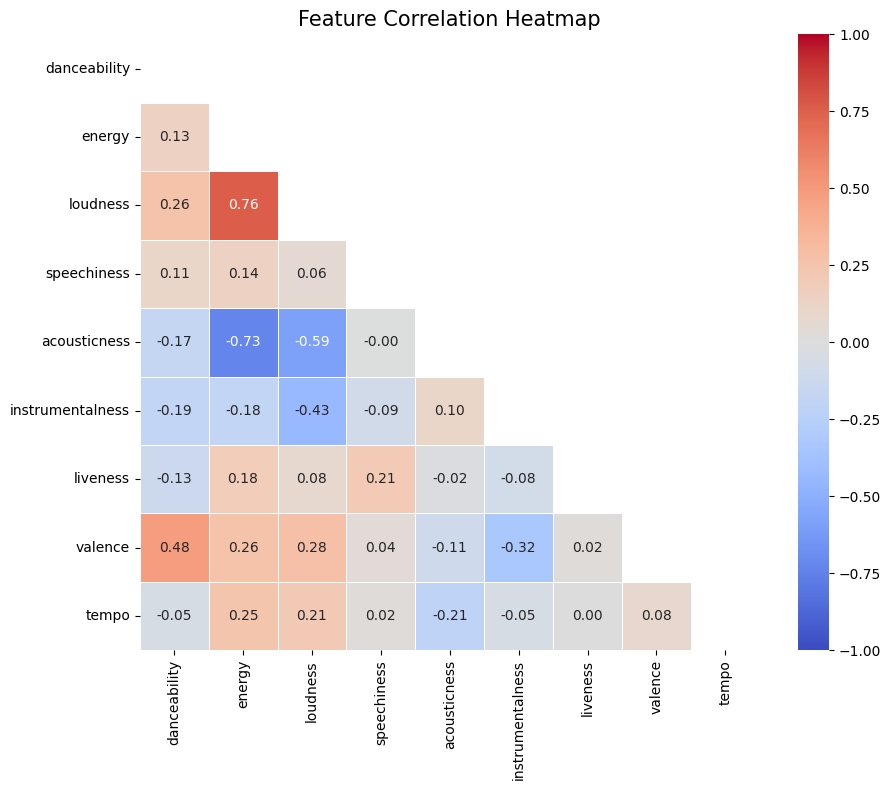

In [10]:
corr = data[AUDIO_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.5)

ax.set_title("Feature Correlation Heatmap", fontsize=15)
plt.savefig("../outputs/figures/02_feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Key Heatmap Takeaways
- Loudness and Energy have the highest positive correlation (0.76). This suggests that both features are measuring the same perceptual thing. To prevent energy dimension from voting twice in our calculations, we drop the 'loudness' feature.
- We chose to drop 'loudness' rather than 'energy' as energy is a bound feature around (0 , 1) while loudness is in dB which is noisier for our clustering algorithm.

In [11]:
AUDIO_FEATURES.remove('loudness')
print(AUDIO_FEATURES)

['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [12]:
VISUALIZABLE_FEATURES = [
    "danceability", "energy", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence"
]
# Note: excluding tempo here since it's on a different scale (BPM) which would visually dominate a radar chart

genre_means = data.groupby("track_genre")[VISUALIZABLE_FEATURES].mean()
print(genre_means.round(3))

             danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence
track_genre                                                                                      
acoustic            0.550   0.435        0.043         0.567             0.038     0.153    0.424
afrobeat            0.670   0.703        0.087         0.271             0.253     0.185    0.699
alt-rock            0.534   0.754        0.055         0.122             0.054     0.210    0.518
alternative         0.560   0.720        0.070         0.148             0.038     0.201    0.496
ambient             0.368   0.237        0.042         0.777             0.676     0.129    0.167
...                   ...     ...          ...           ...               ...       ...      ...
techno              0.684   0.746        0.064         0.081             0.540     0.159    0.322
trance              0.583   0.845        0.080         0.036             0.424     0.234    0.277
trip-hop            

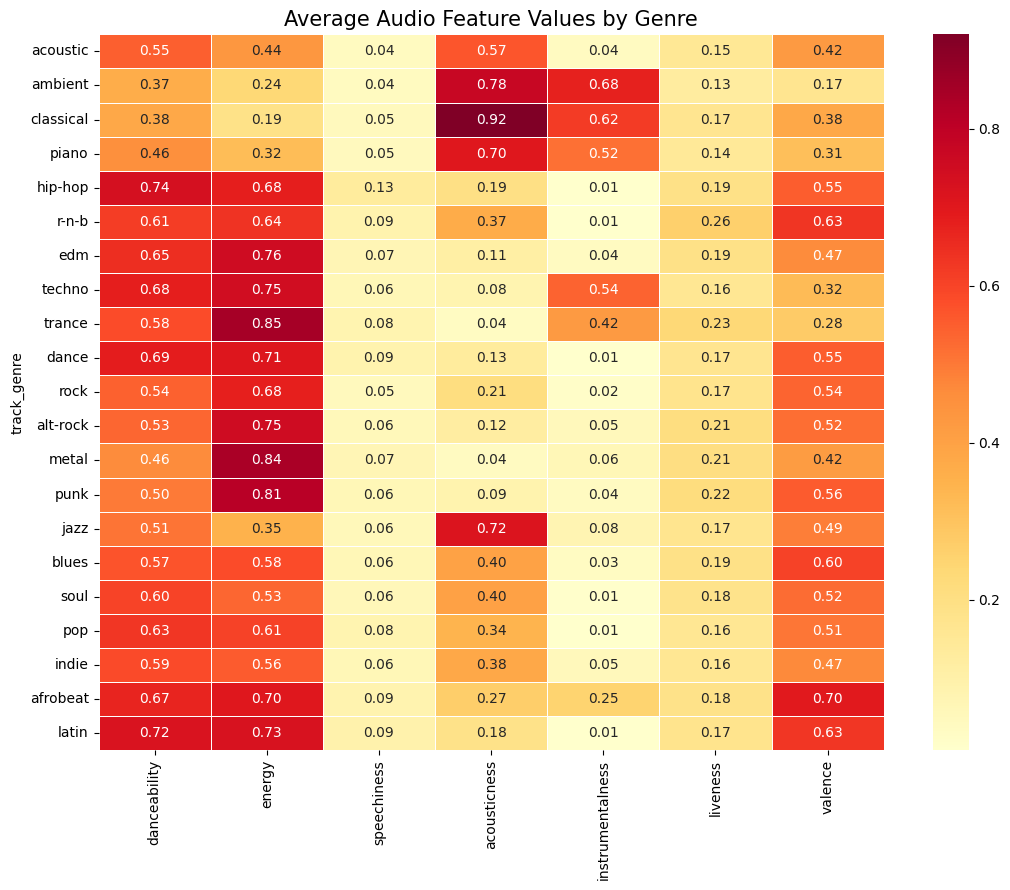

In [13]:
# 114 genres in total - too complicated to visualize, so let's take a subset of these
SELECTED_GENRES = [
    "acoustic", "ambient", "classical", "piano",       # quiet / acoustic end
    "hip-hop", "rap", "r-n-b",                         # rhythm / speech heavy
    "edm", "techno", "trance", "dance",                # electronic / high energy
    "rock", "alt-rock", "metal", "punk",               # high energy / guitar
    "jazz", "blues", "soul",                           # organic / expressive
    "pop", "indie", "afrobeat", "latin"                # mainstream / diverse
]

genre_means_subset = genre_means.loc[
    [g for g in SELECTED_GENRES if g in genre_means.index]
]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(genre_means_subset, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Average Audio Feature Values by Genre", fontsize=15)
plt.tight_layout()
plt.savefig("../outputs/figures/03_genre_feature_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## EDA Key Takeaways

### Dataset

- **Shape:** 113999 tracks and 20 features (after dropping index column and null rows)
- **Audio features used:** danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence, tempo
- **Dropped before modeling:** loudness, key, mode, time_signature + all metadata columns 

### Feature Distributions

| Feature | Shape | Preprocessing implication |
|---|---|---|
| `danceability` | Roughly normal, wide spread | None |
| `energy` | Left-skewed (high-energy bias) | None |
| `valence` | Flat / roughly uniform | None |
| `tempo` | Roughly normal, spike ~120 BPM | None |
| `speechiness` | Zero-inflated, long right tail | `log1p` transform |
| `acousticness` | Zero-inflated, long right tail | `log1p` transform |
| `instrumentalness` | Severely zero-inflated | `log1p` transform |
| `liveness` | Zero-inflated, long right tail | `log1p` transform |

> **Why log1p?** Zero-inflated features compress most of their variation into a small range near 0. K-Means distance calculations treat these tracks as nearly identical. `log1p` stretches the crowded near-zero region out so subtle differences become meaningful to the algorithm.

### Correlation Heatmap

| Pair | Correlation | Decision |
|---|---|---|
| `energy` ↔ `loudness` | **+0.76** | Drop `loudness` (redundant proxy for `energy`) |
| `energy` ↔ `acousticness` | **-0.73** | Keep both (independent enough, opposite ends of production spectrum) |
| `loudness` ↔ `acousticness` | -0.59 | Resolved by dropping `loudness` |
| All other pairs | < \|0.5\| | No action needed |

### Genre Audio Profiles

- **114 unique genres** — too many for a radar chart; visualized as a heatmap on a representative 21-genre subset
- Genres show **clearly distinct audio fingerprints**, confirming that audio features carry genuine genre signal
- Natural poles visible in the heatmap:
 
| Pole | Genres | Signature |
|---|---|---|
| Acoustic | `classical`, `ambient`, `acoustic`, `piano` | High acousticness, high instrumentalness, low energy |
| Rhythm / Speech | `hip-hop`, `r-n-b` | High danceability, high speechiness, low acousticness |
| Electronic | `techno`, `trance`, `edm` | High energy, high instrumentalness, low acousticness |
| High Energy | `metal`, `punk`, `rock` | High energy, low acousticness, low instrumentalness |
| Mainstream / Diverse | `latin`, `pop`, `afrobeat` | Balanced across features, high valence |
 
> This validates the core project assumption — **if genres are acoustically distinct, an unsupervised algorithm can recover meaningful groupings without ever seeing a genre label.**

### Decisions Carried Forward into Preprocessing
 
1. **Drop:** `loudness`, `key`, `mode`, `time_signature`, and all metadata columns
2. **Log1p transform:** `speechiness`, `acousticness`, `instrumentalness`, `liveness`
3. **StandardScaler:** all 8 features after transformation
4. **PCA:** 2 components for visualization only — clustering runs on full 8-feature scaled matrix
